# Maximum Likelihood Data Fitting in Intro Computational Physics

In this notebook we introduce **data fitting using the Maximum Likelihood (ML) method** and show how to estimate **errors (uncertainties) on fitted parameters**.

We will:

1. Review the idea of a **likelihood** and **maximum likelihood estimation (MLE)**.
2. Work through a simple **Gaussian example**: repeated measurements of a single quantity.
3. Show how to get **parameter errors** from the **shape of the log-likelihood** (curvature and the "Δln L = 0.5" rule).
4. Connect this to the familiar **least-squares / χ²** method used with Gaussian errors.

This level of detail is appropriate for an **introductory computational physics** course.

## 1. Basic idea of Maximum Likelihood

Suppose you have data points
\begin{equation}
x_1, x_2, \dots, x_N
\end{equation}
which you believe are drawn from some probability distribution that depends on an unknown parameter $\theta$.

- The **likelihood** $L(\theta)$ is the probability of getting the observed data, *viewed as a function of the parameter* $\theta$.
- In the case of **independent** data points,
\begin{equation}
L(\theta) = P(x_1,\dots,x_N \mid \theta) = \prod_{i=1}^N p(x_i \mid \theta).
\end{equation}

The **Maximum Likelihood Estimator (MLE)** is the value $\hat{\theta}$ that **maximizes** $L(\theta)$ (or equivalently, maximizes the log-likelihood $\ln L(\theta)$).

Because products of many small probabilities can underflow, and because logs turn products into sums, **we almost always work with the log-likelihood**:
\begin{equation}
\ell(\theta) \equiv \ln L(\theta) = \sum_{i=1}^N \ln p(x_i \mid \theta).
\end{equation}

We typically **maximize** $\ell(\theta)$ numerically, or sometimes we can solve for $\hat{\theta}$ analytically.

## 2. Example: Gaussian measurements of a single quantity

Imagine we measure some physical quantity $\mu$ (for example, the length of a rod or the voltage from a source). We get $N$ measurements
\begin{equation}
x_1, x_2, \dots, x_N
\end{equation}
and we assume that each measurement is Gaussian distributed about the true value $\mu$ with a **known** standard deviation $\sigma$:
\begin{equation}
p(x_i \mid \mu) = \frac{1}{\sqrt{2\pi}\sigma} \exp\left( -\frac{(x_i - \mu)^2}{2\sigma^2} \right).
\end{equation}

Then the log-likelihood for $\mu$ is
\begin{equation}
\ell(\mu) = \sum_{i=1}^N \ln p(x_i \mid \mu) = \text{const} - \frac{1}{2\sigma^2} \sum_{i=1}^N (x_i - \mu)^2.
\end{equation}

Maximizing $\ell(\mu)$ is the same as **minimizing** the sum of squared residuals:
\begin{equation}
\sum_{i=1}^N (x_i - \mu)^2.
\end{equation}

You can show (by taking a derivative and setting it to zero) that the MLE for $\mu$ is just the **sample mean**:
\begin{equation}
\hat{\mu} = \frac{1}{N} \sum_{i=1}^N x_i.
\end{equation}

Let's see this numerically.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(12345)

# True parameters
mu_true = 1.5
sigma = 0.3
N = 50

# Generate synthetic Gaussian data: measurements of mu_true with known sigma
x_data = rng.normal(loc=mu_true, scale=sigma, size=N)

print("First 10 data points:")
print(x_data[:10])
print("\nSample mean (our MLE for mu):", np.mean(x_data))

First 10 data points:
[1.07285249 1.87911854 1.23880148 1.42224803 1.47739701 1.2777346
 1.08966219 1.69466784 1.60831743 0.91414108]

Sample mean (our MLE for mu): 1.5181370353658357


Now let's explicitly construct the **log-likelihood** as a function of $\mu$, and plot it. We'll see that it is maximized at $\hat{\mu} = \bar{x}$ (the sample mean).

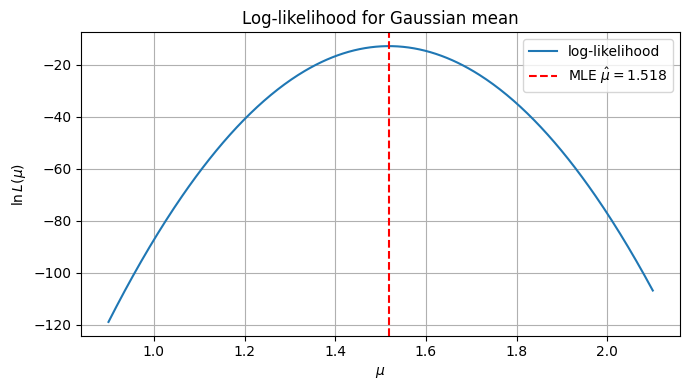

In [2]:
def log_likelihood_gaussian_mu(mu, x, sigma):
    """Log-likelihood for a set of Gaussian data with known sigma and mean mu."""
    # constant terms can be ignored if we only care about relative shapes,
    # but here we'll keep them for completeness
    n = len(x)
    return -0.5 * n * np.log(2 * np.pi * sigma**2) - np.sum((x - mu)**2) / (2 * sigma**2)

# Scan a range of mu values around the sample mean
mu_grid = np.linspace(mu_true - 0.6, mu_true + 0.6, 400)
ll_values = np.array([log_likelihood_gaussian_mu(mu, x_data, sigma) for mu in mu_grid])

mu_hat = np.mean(x_data)
ll_hat = log_likelihood_gaussian_mu(mu_hat, x_data, sigma)

plt.figure(figsize=(7,4))
plt.plot(mu_grid, ll_values, label="log-likelihood")
plt.axvline(mu_hat, color="red", linestyle="--", label=fr"MLE $\hat{{\mu}}={mu_hat:.3f}$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\ln L(\mu)$")
plt.title("Log-likelihood for Gaussian mean")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

You should see that the log-likelihood is a **concave quadratic** in $\mu$, with its maximum very close to the sample mean.

---

## 3. Parameter errors from the log-likelihood shape

Now we address the key question:

> **How do we get an error bar on the fitted parameter $\hat{\mu}$?**

In maximum likelihood theory, for large samples, the uncertainty $\sigma_{\mu}$ is related to the **curvature** of the log-likelihood at the maximum.

For a 1D parameter $\theta$ (here $\mu$), the idea is:
\begin{equation}
\sigma_\theta^2 \approx -\left( \frac{\partial^2 \ell(\theta)}{\partial \theta^2} \right)^{-1}_{\theta=\hat{\theta}}.
\end{equation}

Intuitively:
- A **sharp** peak (large negative second derivative) means **small uncertainty**.
- A **broad** peak (small curvature) means **large uncertainty**.

In the Gaussian mean example, you can show analytically that
\begin{equation}
\sigma_\mu = \frac{\sigma}{\sqrt{N}}.
\end{equation}

We will now show how to approximate $\sigma_\mu$ numerically using two common approaches:

1. **Curvature method** (second derivative of log-likelihood), and
2. The **Δln L = 0.5 rule** for a 1-parameter fit.

For a single parameter, a **1σ (68%) confidence interval** is approximately given by the region where the **log-likelihood drops by 0.5**:
\begin{equation}
\ell(\theta) = \ell(\hat{\theta}) - \frac{1}{2}.
\end{equation}

We will demonstrate this graphically.

In [3]:
# Numerical estimation of the curvature (second derivative) at mu_hat

def second_derivative(f, x, h=1e-4):
    """Numerical second derivative of f at x using central differences."""
    return (f(x + h) - 2*f(x) + f(x - h)) / h**2

def ll_mu(mu):
    return log_likelihood_gaussian_mu(mu, x_data, sigma)

d2_ll_dmu2 = second_derivative(ll_mu, mu_hat)
sigma_mu_curvature = np.sqrt(-1.0 / d2_ll_dmu2)

print("Numerical curvature at mu_hat:", d2_ll_dmu2)
print("Estimated sigma_mu from curvature:", sigma_mu_curvature)
print("Analytic sigma/sqrt(N):", sigma / np.sqrt(N))

Numerical curvature at mu_hat: -555.5555560476932
Estimated sigma_mu from curvature: 0.04242640685240118
Analytic sigma/sqrt(N): 0.04242640687119285


The numerical estimate from the curvature should be close to the familiar result $\sigma_\mu = \sigma/\sqrt{N}$.

Now let's use the **Δln L = 0.5** rule to find a 1σ confidence interval for $\mu$.

mu_hat = 1.5181370353658357
Left crossing mu_L ~ 1.4744360902255642
Right crossing mu_R ~ 1.5616541353383462
Estimated sigma_mu from Δln L=0.5: 0.043609022556390986
Analytic sigma/sqrt(N): 0.04242640687119285


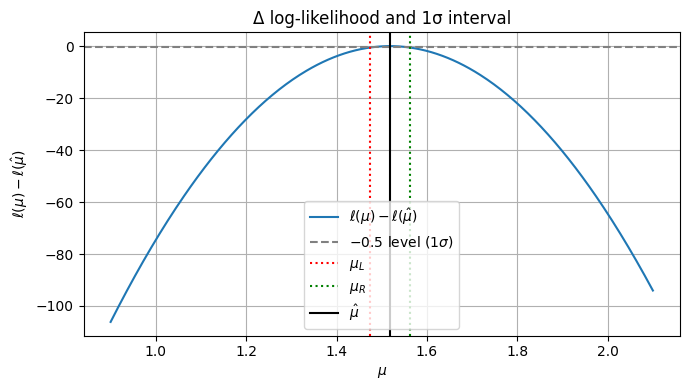

In [4]:
# Use the delta log-likelihood method to estimate 1σ interval

delta_ll = ll_values - ll_hat  # log-likelihood relative to the maximum

# Find where log-likelihood drops by 0.5 from the maximum
target = -0.5

# We'll look for the grid points closest to where delta_ll crosses -0.5 on each side
left_mask = mu_grid < mu_hat
right_mask = mu_grid > mu_hat

mu_left_candidates = mu_grid[left_mask]
dll_left_candidates = delta_ll[left_mask]
mu_right_candidates = mu_grid[right_mask]
dll_right_candidates = delta_ll[right_mask]

mu_left = mu_left_candidates[np.argmin(np.abs(dll_left_candidates - target))]
mu_right = mu_right_candidates[np.argmin(np.abs(dll_right_candidates - target))]

sigma_mu_delta_ll = 0.5 * (mu_right - mu_left)

print("mu_hat =", mu_hat)
print("Left crossing mu_L ~", mu_left)
print("Right crossing mu_R ~", mu_right)
print("Estimated sigma_mu from Δln L=0.5:", sigma_mu_delta_ll)
print("Analytic sigma/sqrt(N):", sigma / np.sqrt(N))

plt.figure(figsize=(7,4))
plt.plot(mu_grid, delta_ll, label=r"$\ell(\mu) - \ell(\hat{\mu})$")
plt.axhline(-0.5, color="gray", linestyle="--", label=r"$-0.5$ level (1$\sigma$)")
plt.axvline(mu_left, color="red", linestyle=":", label=r"$\mu_L$")
plt.axvline(mu_right, color="green", linestyle=":", label=r"$\mu_R$")
plt.axvline(mu_hat, color="black", linestyle="-", label=r"$\hat{\mu}$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\ell(\mu) - \ell(\hat{\mu})$")
plt.title("Δ log-likelihood and 1σ interval")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

We now have two ways to estimate the **error on the fitted parameter $\mu$**:

1. Using the **curvature** (second derivative) of the log-likelihood at the maximum (via the inverse Hessian).
2. Using the **Δln L = 0.5** contour for a 1-parameter fit.

Both give results close to the known analytic formula $\sigma_\mu = \sigma/\sqrt{N}$ in this simple example.

---

## 4. Connection to least-squares and χ² fits

In many physics problems, we have **y vs x data** with Gaussian errors on $y$ and a model $y = f(x; \theta)$ depending on one or more parameters $\theta$.

For example, a straight line model:
\begin{equation}
y = a x + b.
\end{equation}

Assume each $y_i$ has a Gaussian error with known standard deviation $\sigma_i$, and the errors are independent. Then the likelihood is
\begin{equation}
L(a,b) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi}\sigma_i} \exp\left( -\frac{(y_i - a x_i - b)^2}{2\sigma_i^2} \right).
\end{equation}

The log-likelihood is
\begin{equation}
\ell(a,b) = \text{const} - \frac{1}{2} \sum_{i=1}^N \frac{(y_i - a x_i - b)^2}{\sigma_i^2}.
\end{equation}

Maximizing $\ell(a,b)$ is the same as **minimizing** the familiar **χ²**:
\begin{equation}
\chi^2(a,b) = \sum_{i=1}^N \frac{(y_i - a x_i - b)^2}{\sigma_i^2}.
\end{equation}

So **least-squares fitting with Gaussian errors is a special case of maximum likelihood**.

In practice, fitting codes (e.g., `scipy.optimize.curve_fit`) return **best-fit parameters** and a **covariance matrix** that comes from the curvature of χ² (or equivalently, of the log-likelihood). The **diagonal elements** of this covariance matrix are the **variances of the parameters**, and the **square roots** of those are the **standard errors** (1σ uncertainties).

Below is a simple example using a straight-line fit with Gaussian errors, showing how the **parameter errors** come from the **covariance matrix** returned by `curve_fit`.

True parameters: a=2.0, b=1.0
Fitted parameters: a_hat=2.029 ± 0.037, b_hat=0.933 ± 0.107


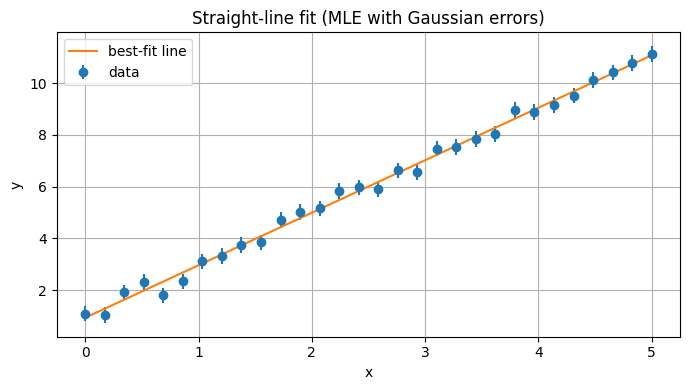

In [5]:
from scipy.optimize import curve_fit

# Generate synthetic line data with Gaussian errors
rng = np.random.default_rng(42)
a_true = 2.0
b_true = 1.0
N_line = 30
x_line = np.linspace(0, 5, N_line)
sigma_y = 0.3  # same sigma for all points
y_line = a_true * x_line + b_true + rng.normal(0, sigma_y, size=N_line)

def line_model(x, a, b):
    return a * x + b

# Perform a least-squares (maximum likelihood) fit assuming Gaussian errors
popt, pcov = curve_fit(line_model, x_line, y_line, sigma=np.full_like(y_line, sigma_y), absolute_sigma=True)

a_hat, b_hat = popt
sigma_a, sigma_b = np.sqrt(np.diag(pcov))

print(f"True parameters: a={a_true}, b={b_true}")
print(f"Fitted parameters: a_hat={a_hat:.3f} ± {sigma_a:.3f}, b_hat={b_hat:.3f} ± {sigma_b:.3f}")

# Plot the data and the fitted line
x_fine = np.linspace(0, 5, 200)
y_fit = line_model(x_fine, a_hat, b_hat)

plt.figure(figsize=(7,4))
plt.errorbar(x_line, y_line, yerr=sigma_y, fmt="o", label="data")
plt.plot(x_fine, y_fit, label="best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Straight-line fit (MLE with Gaussian errors)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The matrix `pcov` returned by `curve_fit` is the **covariance matrix** of the parameters:
\begin{equation}
C = \begin{pmatrix}
\sigma_a^2 & \text{Cov}(a,b) \\
\text{Cov}(a,b) & \sigma_b^2
\end{pmatrix}.
\end{equation}
The **standard errors** are
\begin{equation}
\sigma_a = \sqrt{C_{aa}}, \quad \sigma_b = \sqrt{C_{bb}}.
\end{equation}

Conceptually, this covariance matrix comes from the **inverse of the Hessian** (matrix of second derivatives) of the **negative log-likelihood** (or equivalently, of χ²/2) evaluated at the maximum.

---

## 5. Summary

1. **Maximum likelihood** chooses the parameter values that make the observed data **most probable** under your statistical model.
2. For **independent data**, the log-likelihood is a sum over data points.
3. In many physics problems with **Gaussian errors**, MLE is equivalent to **least-squares / χ² fitting**.
4. **Parameter errors** (uncertainties) come from the **curvature of the log-likelihood** at the maximum:
   - For one parameter, $\sigma_\theta^2 \approx -1 / (\partial^2 \ell / \partial \theta^2)$.
   - Equivalently, the 1σ region corresponds approximately to **Δln L = 0.5**.
5. For multi-parameter problems, the **covariance matrix** of the parameters is (approximately) the **inverse Hessian** of the negative log-likelihood. The **diagonal elements** give the **variances** of the parameters.

This framework generalizes beyond Gaussians to **Poisson data, binomial data, exponential distributions, etc.**, which is why maximum likelihood is so widely used in experimental and computational physics.

---

**Exercise ideas for students:**

1. Replace the Gaussian mean example with **exponential decay times** and derive the MLE for the lifetime.
2. For the straight-line fit, generate many pseudo-data sets and study the distribution of the fitted parameters $a$ and $b$; verify that their spread matches the predicted standard errors from the covariance matrix.
3. Try a **Poisson likelihood** example: fitting a constant rate to count data and comparing the ML estimate with the sample mean.